# 01 -- Признаки и протокол валидации

Порядок действий: зафиксировать корпус → нормализовать запросы → разделить пары → построить
поведенческие признаки только по `base`. Метаданные всех документов можно индексировать:
в задаче корпус известен до запросов. Выбор пользователем -- обучающий сигнал, его из holdout не беру.

Префикс `fe_`. Никаких зависимостей от переменных `00`.

In [1]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

fe_root = Path.cwd() if (Path.cwd() / 'notebooks').exists() else Path.cwd().parent
get_ipython().run_line_magic('run', str(fe_root / 'notebooks/common.ipynb'))

fe_out = fe_root / 'outputs'
fe_seed = 143


In [2]:
import hashlib

fe_train, fe_queries, fe_benchmark = load_raw()
fe_q = prepare_queries(fe_train)
fe_pairs = fe_q.copy()
fe_pairs['item_id'] = fe_train.item_id.to_numpy()
fe_pairs = fe_pairs.drop_duplicates(['context_key', 'item_id']).reset_index(drop=True)
fe_catalog = (
    pd.concat(
        [fe_benchmark, fe_train[[c for c in fe_train if c.startswith('item_')]]],
        ignore_index=True,
    )
    .drop_duplicates('item_id')
    .sort_values('item_id')
    .reset_index(drop=True)
)
assert fe_catalog.item_id.is_unique

fe_signature = hashlib.sha256(
    (
        ''.join(
            sha256_file(data_dir() / f'{name}.parquet')
            for name in ['train', 'benchmark_queries', 'benchmark_items']
        )
        + sha256_file(fe_root / 'notebooks/common.ipynb')
    ).encode()
).hexdigest()
fe_manifest_path = fe_out / 'cache/prepared_manifest.json'


In [3]:
fe_saved_manifest = (
    json.loads(fe_manifest_path.read_text()) if fe_manifest_path.exists() else {}
)
if (
    fe_saved_manifest.get('signature') == fe_signature
    and (fe_out / 'cache/item_features.parquet').exists()
):
    fe_items = pd.read_parquet(fe_out / 'cache/items.parquet')
    fe_numeric = pd.read_parquet(fe_out / 'cache/item_features.parquet')
else:
    fe_items = prepare_items(fe_catalog)
    fe_items.to_parquet(fe_out / 'cache/items.parquet', index=False)
    fe_numeric = item_features(fe_items)
    fe_numeric.to_parquet(fe_out / 'cache/item_features.parquet', index=False)
write_json({'signature': fe_signature}, fe_manifest_path)
fe_bq = prepare_queries(fe_queries)
fe_bq.to_parquet(fe_out / 'cache/benchmark_queries.parquet', index=False)
display(fe_numeric.describe().T)


,count,mean,std,min,25%,50%,75%,max
item_price_missing,515895.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
item_price_unknown,515895.0,0.073750,0.261363,0.000000,0.000000,0.000000,0.000000,1.000000
item_price_log1p,477848.0,6.882732,1.831001,0.000000,6.216606,6.908755,7.824446,27.631021
item_price_zero,515895.0,0.008686,0.092792,0.000000,0.000000,0.000000,0.000000,1.000000
item_rating_reviews_count_missing,515895.0,0.052133,0.222295,0.000000,0.000000,0.000000,0.000000,1.000000
item_rating_reviews_count_log1p,489000.0,3.032036,1.494951,0.000000,1.945910,2.995732,4.043051,9.814219
item_rating_reviews_count_zero,515895.0,0.024408,0.154313,0.000000,0.000000,0.000000,0.000000,1.000000
rating,475607.0,4.793191,0.721136,0.000000,4.875000,5.000000,5.000000,5.000000
rating_missing,515895.0,0.078093,0.268319,0.000000,0.000000,0.000000,0.000000,1.000000
rating_shrunk,515895.0,4.951576,0.096036,3.281482,4.934783,5.000000,5.000000,5.000000


## Признаки со смыслом

| Группа | Признаки | Зачем |
|---|---|---|
| Текст | отдельные title, params, description; длины и пустота | короткий заголовок точнее, описание полнее |
| Цена | log1p, 0, missing/служебная -1, отклонение от медианы microcategory | сопоставлять цену внутри типа услуг |
| Репутация | рейтинг, log reviews, missing, сглаженный рейтинг | пять звезд при одном отзыве не равны пяти при тысяче |
| Контакт | hidden phone, forbidden messages, оба флага | доступность способов связи, без жесткого исключения |
| Query--item | покрытие слов по каждому полю, совпадения location/category | релевантность и контекст |
| География | haversine до медианного центра location из каталога | только приблизительная дистанция; координат запроса нет |
| Фильтры | длина, запрошенный порог рейтинга, запас до порога | разделяю «не проходит» и «неизвестно» |
| Поведение | популярность, история текста/контекста, похожие запросы | только на разрешенной обучающей части |

Нормализация: Unicode NFKC, lower, замена U+0451 на U+0435, пробелы. Числа сохраняются. Не транслитерирую
все подряд, не выкидываю отрицания. Символьный поиск компенсирует часть морфологии.

## Warm и cold без повторения полного контекста

`cold`: целиком отложенный нормализованный текст со всеми контекстами.
`warm`: целиком отложенный контекст (текст + все фильтры + локация) знакомого текста.
Один и тот же полный контекст не встречается в base. Исторический выбор того же item
по другому контексту допустим: это доступный behavioral сигнал. Отдельно публикую долю
новых (text, item) и Recall на них: общий warm score может быть оптимистичнее cold.
Проверка только новых пар сделала бы history всегда ошибочным и обучила fusion подавлять его.

Тексты `rank_train`, `dev`, `test` не пересекаются друг с другом. У warm есть другие контексты
в base. `dev` выбирает модель и параметры, `test` открывается только после выбора.
Выбираю не больше одного контекста на текст: в benchmark тексты тоже уникальны.
Полный список отложенных пар сохраняется; выборка для оценки не возвращает остальные пары в base.

In [4]:
def fe_hash(value):
    return int(hashlib.sha256(('143|' + value).encode()).hexdigest()[:16], 16)


fe_texts = fe_pairs.text_key.drop_duplicates()
fe_text_hash = fe_texts.map(fe_hash)
fe_role_by_text = dict(
    zip(fe_texts, fe_text_hash.map(lambda h: ['rank_train', 'dev', 'test'][h % 3]))
)
fe_cold_by_text = dict(zip(fe_texts, fe_text_hash.map(lambda h: (h // 3) % 100 < 15)))
fe_hold_pair = fe_pairs.context_key.map(fe_hash).mod(5).eq(0)
fe_is_cold = fe_pairs.text_key.map(fe_cold_by_text)
fe_role = fe_pairs.text_key.map(fe_role_by_text)
fe_has_base = set(fe_pairs.loc[~fe_is_cold & ~fe_hold_pair, 'text_key'])
fe_is_warm = ~fe_is_cold & fe_hold_pair & fe_pairs.text_key.isin(fe_has_base)
fe_pairs['split'] = np.where(fe_is_cold | fe_is_warm, fe_role, 'base')
fe_pairs['regime'] = np.where(fe_is_cold, 'cold', 'warm')
fe_base = fe_pairs[fe_pairs.split.eq('base')].copy()
fe_eval = []
for fe_split, fe_limit in [('rank_train', 2200), ('dev', 1000), ('test', 1000)]:
    for fe_regime in ['warm', 'cold']:
        fe_part = fe_pairs[fe_pairs.split.eq(fe_split) & fe_pairs.regime.eq(fe_regime)]
        fe_contexts = fe_part.drop_duplicates('context_key').sort_values('context_key')
        fe_contexts = (
            fe_contexts.sample(frac=1, random_state=fe_seed)
            .drop_duplicates('text_key')
            .head(fe_limit)
        )
        fe_eval.append(fe_contexts)


In [5]:
fe_eval = pd.concat(fe_eval, ignore_index=True)
assert fe_eval.query_id.is_unique
assert not set(fe_base.text_key) & set(
    fe_eval.loc[fe_eval.regime.eq('cold'), 'text_key']
)
assert set(fe_eval.loc[fe_eval.regime.eq('warm'), 'text_key']) <= set(fe_base.text_key)
assert not set(fe_base.context_key) & set(
    fe_pairs.loc[fe_pairs.split.ne('base'), 'context_key']
)
assert not set(zip(fe_base.context_key, fe_base.item_id)) & set(
    zip(
        fe_pairs.loc[fe_pairs.split.ne('base'), 'context_key'],
        fe_pairs.loc[fe_pairs.split.ne('base'), 'item_id'],
    )
)
for fe_a, fe_b in [('rank_train', 'dev'), ('rank_train', 'test'), ('dev', 'test')]:
    assert not set(fe_eval.loc[fe_eval.split.eq(fe_a), 'text_key']) & set(
        fe_eval.loc[fe_eval.split.eq(fe_b), 'text_key']
    )
fe_truth_rows = fe_pairs[
    fe_pairs.query_id.isin(fe_eval.query_id) & fe_pairs.split.ne('base')
]
fe_truth = (
    fe_truth_rows.groupby('query_id').item_id.agg(lambda s: sorted(set(s))).to_dict()
)
fe_allowed = set(fe_items.item_id)
assert all(set(v) <= fe_allowed for v in fe_truth.values())
fe_pairs.to_parquet(fe_out / 'cache/split_pairs.parquet', index=False)


In [6]:
fe_base.to_parquet(fe_out / 'cache/base_pairs.parquet', index=False)
fe_eval.drop(columns='item_id').to_parquet(
    fe_out / 'cache/eval_queries.parquet', index=False
)
write_json(fe_truth, fe_out / 'cache/truth.json')
fe_split_summary = fe_eval.groupby(['split', 'regime']).agg(
    queries=('query_id', 'size')
)
display(fe_split_summary)
fe_split_summary.to_csv(fe_out / 'validation/split_summary.csv')
write_json(
    {
        'catalog_items': len(fe_items),
        'base_pairs': len(fe_base),
        'all_unique_pairs': len(fe_pairs),
        'evaluation_queries': len(fe_eval),
        'context_item_overlap': 0,
        'cold_text_overlap': 0,
        'test_used_for_selection': False,
        'seed': fe_seed,
    },
    fe_out / 'validation/leakage_audit.json',
)


queries
split      regime         
dev        cold       1000
           warm       1000
rank_train cold       2200
           warm       2200
test       cold       1000
           warm       1000

n_relevant  cold_item_fraction  query_train_frequency
split      regime                                                       
dev        cold      1.116000            0.685856                  0.000
           warm      1.155000            0.668238                 50.052
rank_train cold      1.076818            0.694183                  0.000
           warm      1.142727            0.659534                 33.645
test       cold      1.071000            0.665708                  0.000
           warm      1.207000            0.663434                 62.939

<Axes: >

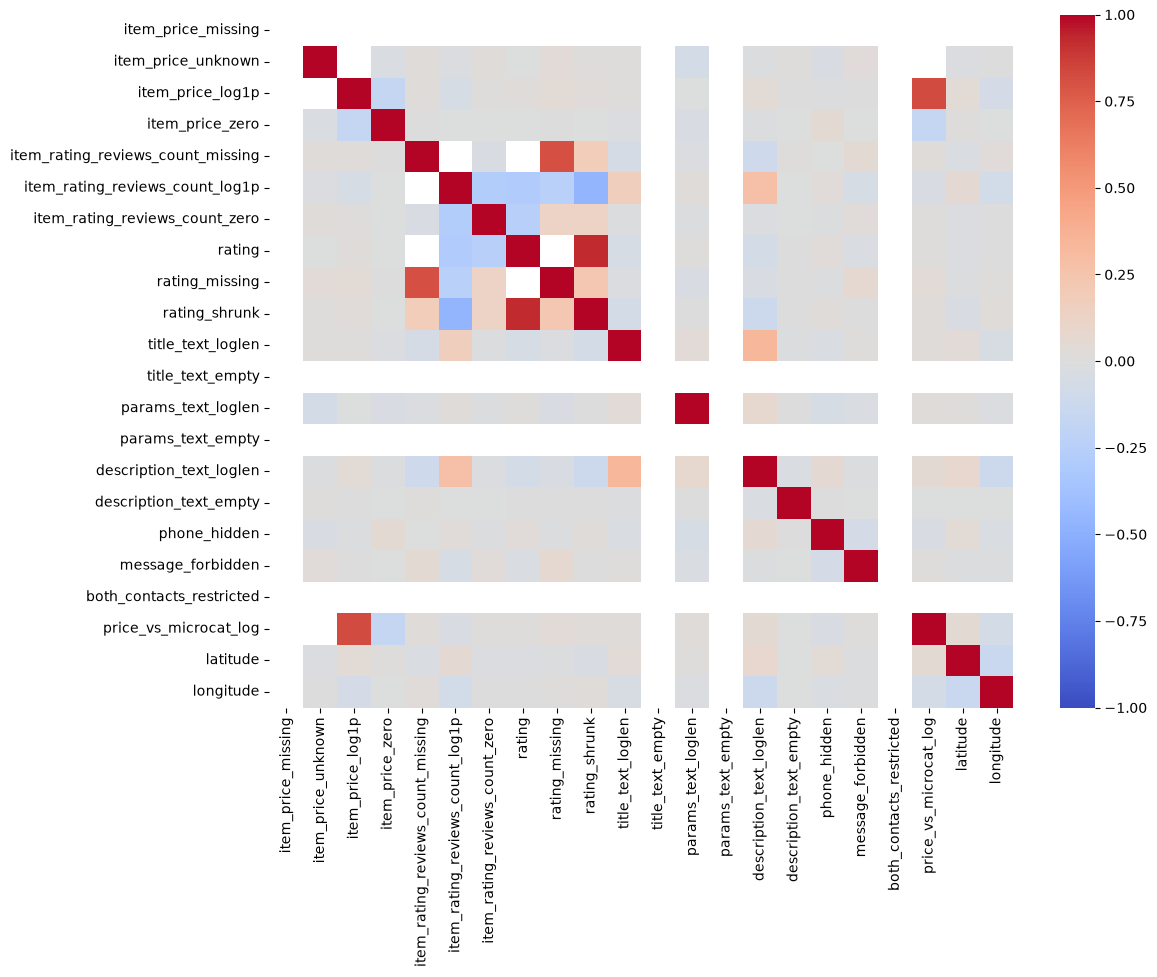

In [7]:
fe_diagnostics = fe_eval[['query_id', 'split', 'regime', 'text_key']].copy()
fe_diagnostics['n_relevant'] = fe_diagnostics.query_id.map(lambda q: len(fe_truth[q]))
fe_seen_items = set(fe_base.item_id)
fe_diagnostics['cold_item_fraction'] = fe_diagnostics.query_id.map(
    lambda q: np.mean([i not in fe_seen_items for i in fe_truth[q]])
)
fe_text_items = fe_base.groupby('text_key').item_id.agg(set).to_dict()
fe_diagnostics['new_pair_fraction'] = [
    np.mean([i not in fe_text_items.get(t, set()) for i in fe_truth[q]])
    for q, t in zip(fe_diagnostics.query_id, fe_diagnostics.text_key)
]
fe_diagnostics['query_train_frequency'] = fe_diagnostics.text_key.map(
    fe_base.text_key.value_counts()
).fillna(0)
fe_diagnostics.to_parquet(fe_out / 'validation/query_slices.parquet', index=False)
display(
    fe_diagnostics.groupby(['split', 'regime'])[
        ['n_relevant', 'cold_item_fraction', 'query_train_frequency']
    ].mean()
)
fe_numeric.corr(method='spearman').to_csv(
    fe_out / 'validation/engineered_correlations.csv'
)
plt.figure(figsize=(12, 9))
import seaborn as sns

sns.heatmap(
    fe_numeric.corr(method='spearman'), cmap='coolwarm', center=0, vmin=-1, vmax=1
)


In [8]:
plt.tight_layout()
plt.savefig(fe_out / 'figures/engineered_correlations.png', dpi=150)
plt.show()


<Figure size 640x480 with 0 Axes>

## Ограничения протокола

Полный локальный корпус больше финального, поэтому задача поиска локально сложнее по числу distractors.
С другой стороны, его состав получен из positive-only train, а не случайной выгрузки всей площадки.
Warm/cold результаты публикую отдельно; среднее не выдаю за leaderboard score.
Даже этот split не проверяет временную устойчивость: времени в данных нет.
Признаки меняющихся объявлений -- статический snapshot, поэтому временную утечку исключить невозможно.